## Imports and paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

In [2]:
PROJECT_DIR = Path.cwd()
UNIFORM_DIR = PROJECT_DIR / "Cleaned Data" / "Uniform column format"
REGION_MANDATE_FILE = PROJECT_DIR / "Cleaned Data" / "002 Data Clean" / "region_mandate_dates.csv"

In [3]:
# 6 Countries
COUNTRIES = {"AUS": "Australia", "BRA": "Brazil", "CAN": "Canada", "GBR": "United Kingdom", "IND": "India", "USA": "United States"}

# Label
DATE_COL = "Date"
REGION_COL = "RegionName"
H6_COL = "H6M_Facial Coverings"

ROLLING_DAYS = 14                                               # 14-day rolling average
MANDATE_THRESHOLD = 2.5                                         # Mandate threshold 

# Colors
MAIN_COLOR = "#1F4E79"
HORIZONTAL_LINE_COLOR = "#8B0000"
DATE_LINE_COLOR = "#D62728"

TITLE_FONTSIZE = 14
AXIS_LABEL_FONTSIZE = 12
TICK_LABEL_FONTSIZE = 10
LEGEND_FONTSIZE = 9
SUPTITLE_FONTSIZE = 18
DATE_TEXT_FONTSIZE = 9

# Regional mandate date visualization
REGION_DATE_CMAP = "viridis"
REGION_LINE_COLOR = "#D9E2F3"
REGION_MEDIAN_COLOR = "#8B0000"
REGION_POINT_SIZE = 82
REGION_DATE_TEXT_FONTSIZE = 8


## 1 Help function

In [4]:
def read_csv_clean(path):
    return pd.read_csv(path, na_values=[" ", "__NA__", ""], keep_default_na=True, low_memory=False)


def is_empty_region(series):
    text = series.astype(str).str.strip().str.lower()
    return series.isna() | text.isin(["", "nan", "none"])


def prepare_policy_data(df, country_name):
    missing_cols = [col for col in [DATE_COL, H6_COL] if col not in df.columns]
    if missing_cols:
        raise ValueError("Error")
    df = df.copy()
    if REGION_COL not in df.columns:
        df[REGION_COL] = np.nan
    df["policy_date"] = pd.to_datetime(df[DATE_COL].astype(str), format="%Y%m%d", errors="coerce")                 # date format
    df[H6_COL] = pd.to_numeric(df[H6_COL], errors="coerce")                                                        # numeric H6
    return df.dropna(subset=["policy_date", H6_COL]).copy()


def compute_region_rolling(df, code, country_name):
    df_region = df[~is_empty_region(df[REGION_COL])].copy()
    if df_region.empty:
        df_region = df.copy()
        df_region[REGION_COL] = country_name
    region_roll_list = []
    for region_name, g in df_region.groupby(REGION_COL):
        g = g.sort_values("policy_date").copy()
        g["rolling_h6"] = g[H6_COL].rolling(window=ROLLING_DAYS, min_periods=ROLLING_DAYS).mean()                  # rolling mean
        g["country_code"], g["country_name"], g["region_name"] = code, country_name, region_name
        region_roll_list.append(g[["country_code", "country_name", "region_name", "policy_date", "rolling_h6"]])
    return pd.concat(region_roll_list, ignore_index=True).dropna(subset=["rolling_h6"]).copy()


def compute_country_mean_from_regions(region_roll):
    return region_roll.groupby("policy_date", as_index=False)["rolling_h6"].mean().sort_values("policy_date")       # country mean

## 2 Clean

In [5]:
country_region_policy = {}
country_thick_policy = {}

for code, country_name in COUNTRIES.items():
    file_path = UNIFORM_DIR / f"OxCGRT_{country_name}.csv"
    if not file_path.exists():
        raise FileNotFoundError("Error")
    df = prepare_policy_data(read_csv_clean(file_path), country_name)                                               # clean data
    region_roll = compute_region_rolling(df, code, country_name)                                                    # region rolling
    country_region_policy[code] = region_roll
    country_thick_policy[code] = compute_country_mean_from_regions(region_roll)                                     # mean series

## 3 Visualization

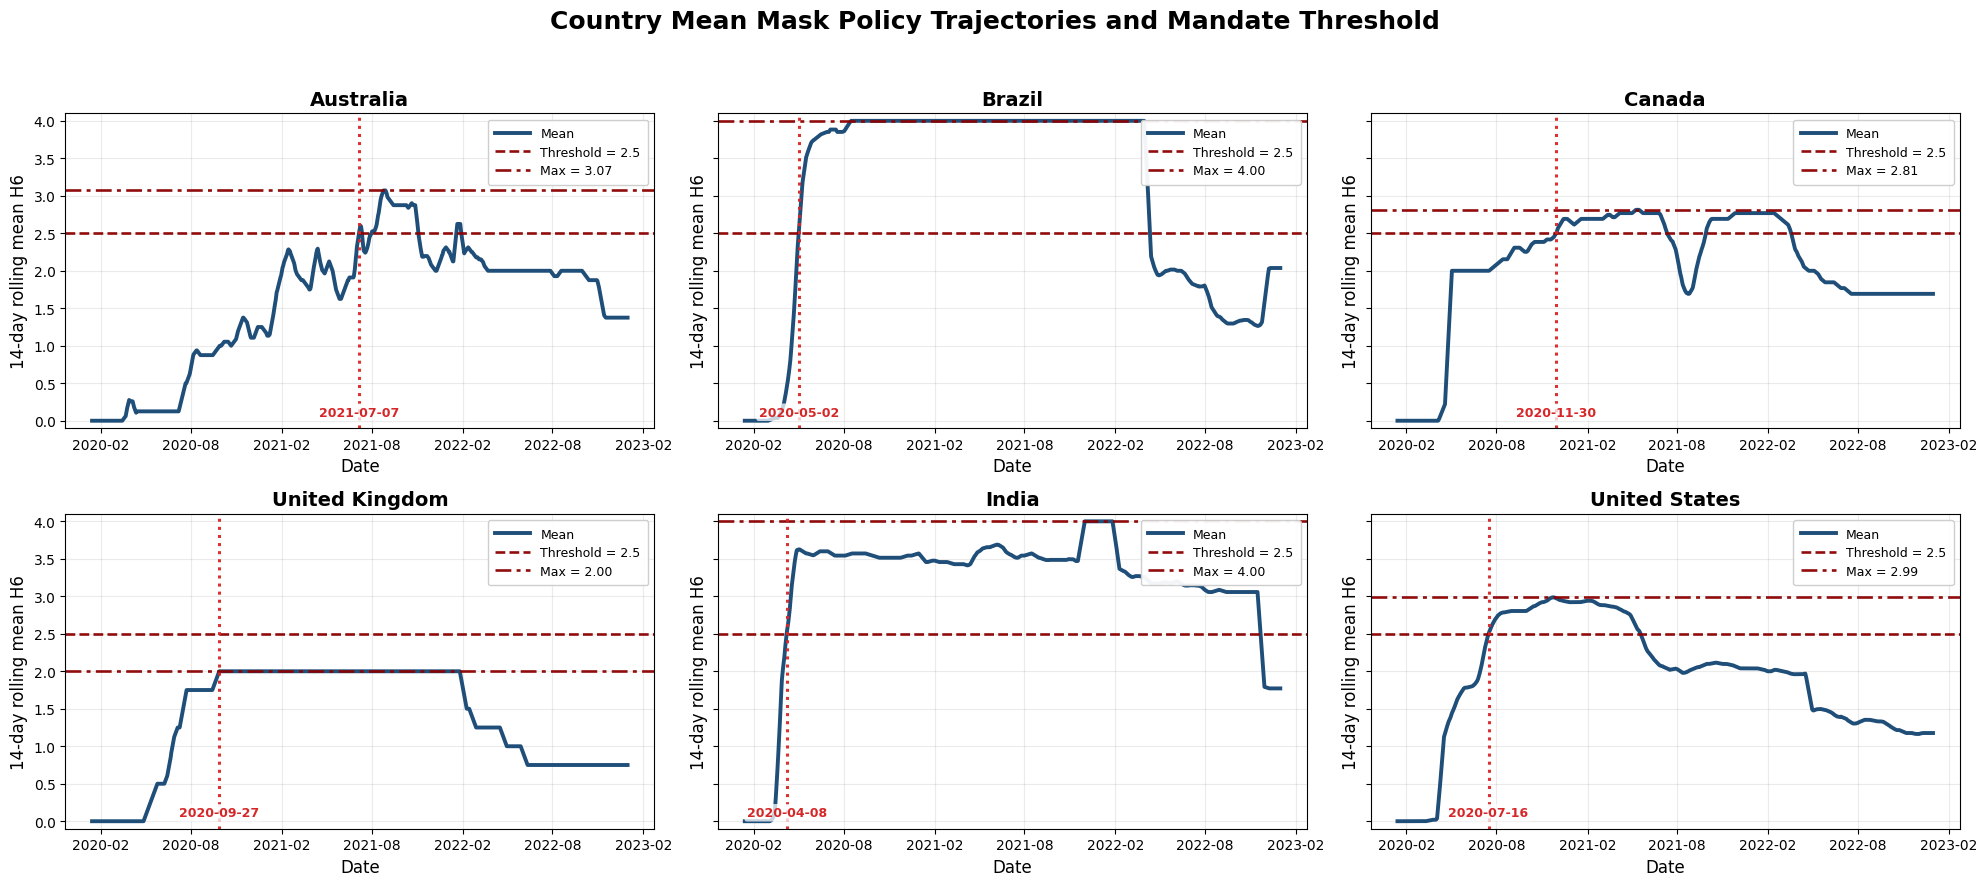

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(20, 9), sharey=True)
axes = axes.flatten()

for ax, (code, country_name) in zip(axes, COUNTRIES.items()):
    thick_roll = country_thick_policy[code].copy()
    max_value = thick_roll["rolling_h6"].max()
    threshold_hit = thick_roll[thick_roll["rolling_h6"] >= MANDATE_THRESHOLD]
    max_hit = thick_roll[thick_roll["rolling_h6"] == max_value]
    candidate_dates = []
    if not threshold_hit.empty:
        candidate_dates.append(threshold_hit["policy_date"].iloc[0])
    if not max_hit.empty:
        candidate_dates.append(max_hit["policy_date"].iloc[0])
    first_intersection_date = min(candidate_dates) if len(candidate_dates) > 0 else None                            # key date

    ax.plot(thick_roll["policy_date"], thick_roll["rolling_h6"], linewidth=2.8, color=MAIN_COLOR, label="Mean")     # mean line
    ax.axhline(MANDATE_THRESHOLD, linestyle="--", linewidth=1.9, color=HORIZONTAL_LINE_COLOR, alpha=0.95, label=f"Threshold = {MANDATE_THRESHOLD}")
    ax.axhline(max_value, linestyle=(0, (6, 2, 1.5, 2)), linewidth=1.9, color=HORIZONTAL_LINE_COLOR, alpha=0.95, label=f"Max = {max_value:.2f}")

    if first_intersection_date is not None:
        ax.axvline(first_intersection_date, linestyle=":", linewidth=2.2, color=DATE_LINE_COLOR, alpha=0.95)        # date line
        ax.text(first_intersection_date, 0.03, first_intersection_date.strftime("%Y-%m-%d"), transform=ax.get_xaxis_transform(), fontsize=DATE_TEXT_FONTSIZE, color=DATE_LINE_COLOR, fontweight="bold", ha="center", va="bottom", rotation=0, bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.75))

    ax.set_title(country_name, fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.set_xlabel("Date", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel("14-day rolling mean H6", fontsize=AXIS_LABEL_FONTSIZE)
    ax.tick_params(axis="both", labelsize=TICK_LABEL_FONTSIZE)
    ax.set_ylim(-0.1, 4.1)
    ax.grid(alpha=0.25)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    for label in ax.get_xticklabels():
        label.set_rotation(0)
        label.set_ha("center")
    ax.legend(fontsize=LEGEND_FONTSIZE, loc="upper right", frameon=True, framealpha=0.95, borderpad=0.6, labelspacing=0.45, handlelength=2.8)

plt.suptitle("Country Mean Mask Policy Trajectories and Mandate Threshold", fontsize=SUPTITLE_FONTSIZE, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 4 Regional mandate start dates

### 4.1 Check errors and prepare data

In [ ]:
if not REGION_MANDATE_FILE.exists():
    raise FileNotFoundError("Error")

mandate_dates = read_csv_clean(REGION_MANDATE_FILE)
required_cols = ["country", "state", "mandate_start_date"]
missing_cols = [col for col in required_cols if col not in mandate_dates.columns]
if missing_cols:
    raise ValueError("Error")

# Clean regional mandate date
mandate_dates = mandate_dates[required_cols].copy()
mandate_dates["country"] = mandate_dates["country"].astype(str).str.strip()
mandate_dates["state"] = mandate_dates["state"].astype(str).str.strip()
mandate_dates["mandate_start_date"] = pd.to_datetime( mandate_dates["mandate_start_date"], errors="coerce")
mandate_dates = mandate_dates.dropna(subset=["country", "state", "mandate_start_date"]).copy()
mandate_dates = mandate_dates[mandate_dates["country"].isin(COUNTRIES.values())].copy()

if mandate_dates.empty:
    raise ValueError("Error")

# Shared date scale
global_start = mandate_dates["mandate_start_date"].min() - pd.Timedelta(days=20)
global_end = mandate_dates["mandate_start_date"].max() + pd.Timedelta(days=55)

date_norm = mcolors.Normalize( vmin=mdates.date2num(mandate_dates["mandate_start_date"].min()), vmax=mdates.date2num(mandate_dates["mandate_start_date"].max()))
date_cmap = plt.get_cmap(REGION_DATE_CMAP)

country_code_lookup = { country_name: code for code, country_name in COUNTRIES.items()}


def Country__date(country_name):
    code = country_code_lookup[country_name]
    thick_roll = country_thick_policy[code].copy()

    max_value = thick_roll["rolling_h6"].max()
    threshold_hit = thick_roll[
        thick_roll["rolling_h6"] >= MANDATE_THRESHOLD]
    max_hit = thick_roll[ thick_roll["rolling_h6"] == max_value]

    candidate_dates = []
    if not threshold_hit.empty:
        candidate_dates.append(threshold_hit["policy_date"].iloc[0])
    if not max_hit.empty:
        candidate_dates.append(max_hit["policy_date"].iloc[0])

    return min(candidate_dates) if candidate_dates else None


def Region_mandate_date(country_name):
    country_data = mandate_dates[mandate_dates["country"] == country_name].sort_values(["mandate_start_date", "state"]).reset_index(drop=True)

    if country_data.empty:
        raise ValueError("Error")

    y_position = np.arange(len(country_data))
    date_number = mdates.date2num(country_data["mandate_start_date"] )
    key_date = Country__date(country_name)
    fig_height = max(6, len(country_data) * 0.42)
    fig, ax = plt.subplots(figsize=(16, fig_height))

    for row_number in range(len(country_data)):
        if row_number % 2 == 0:
            ax.axhspan(row_number - 0.5, row_number + 0.5,  color="#F4F7FA",     alpha=0.85,     zorder=0   )

    # Regional mandate date
    ax.hlines(  y=y_position,  xmin=global_start,    xmax=country_data["mandate_start_date"], color=REGION_LINE_COLOR, linewidth=2.3, zorder=1 )
    ax.scatter( country_data["mandate_start_date"], y_position, c=date_number, cmap=date_cmap, norm=date_norm, s=REGION_POINT_SIZE, edgecolor="white", linewidth=0.9,  zorder=3  )

    # Mean date
    if key_date is not None:
        ax.axvline(  key_date,  linestyle=":",  linewidth=2.2,  color=DATE_LINE_COLOR,  alpha=0.95,  label=f"Mean = {key_date:%Y-%m-%d}" )

    # Date labels
    for y_value, date_value in zip( y_position,  country_data["mandate_start_date"] ):
        ax.annotate( date_value.strftime("%Y-%m-%d"),  xy=(date_value, y_value),  xytext=(7, 0),  textcoords="offset points", fontsize=REGION_DATE_TEXT_FONTSIZE,  color="#333333", va="center" )

    ax.set_title(  f"{country_name}   |  {len(country_data)} regions",  fontsize=SUPTITLE_FONTSIZE, fontweight="bold", loc="left" )
    ax.set_xlabel( "Mandate start date",  fontsize=AXIS_LABEL_FONTSIZE )
    ax.set_ylabel(  "Region", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_yticks(y_position)
    ax.set_yticklabels( country_data["state"], fontsize=TICK_LABEL_FONTSIZE )
    ax.set_xlim(global_start, global_end)
    ax.tick_params( axis="x", labelsize=TICK_LABEL_FONTSIZE )

    ax.xaxis.set_major_locator( mdates.MonthLocator(interval=3) )
    ax.xaxis.set_major_formatter( mdates.DateFormatter("%Y-%m") )
    ax.grid(axis="x", alpha=0.25)
    ax.invert_yaxis()

    if key_date is not None:
        ax.legend( fontsize=LEGEND_FONTSIZE, loc="lower right", frameon=True, framealpha=0.95 )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.35)
    ax.spines["bottom"].set_alpha(0.35)



    color_bar_object = plt.cm.ScalarMappable( norm=date_norm, cmap=date_cmap )
    color_bar_object.set_array([])
    color_bar = fig.colorbar( color_bar_object, ax=ax, orientation="horizontal",  pad=0.12,  fraction=0.035, aspect=45 )
    color_bar_ticks = np.linspace(  date_norm.vmin, date_norm.vmax, 6)
    color_bar.set_ticks(color_bar_ticks)
    color_bar.set_ticklabels([ mdates.num2date(value).strftime("%Y-%m-%d") for value in color_bar_ticks ])
    color_bar.ax.tick_params( labelsize=TICK_LABEL_FONTSIZE)

    plt.tight_layout()
    plt.show()

### 4.2 Australia

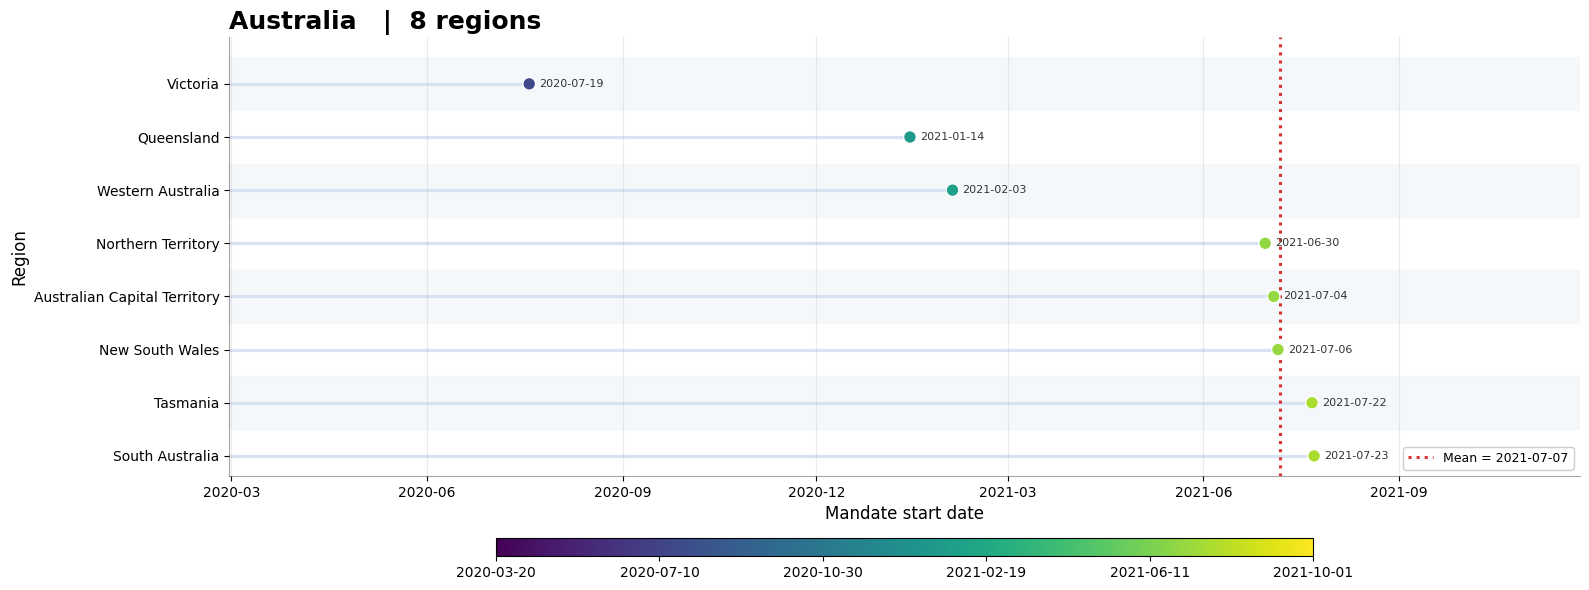

In [13]:
Region_mandate_date("Australia")

### 4.3 Brazil

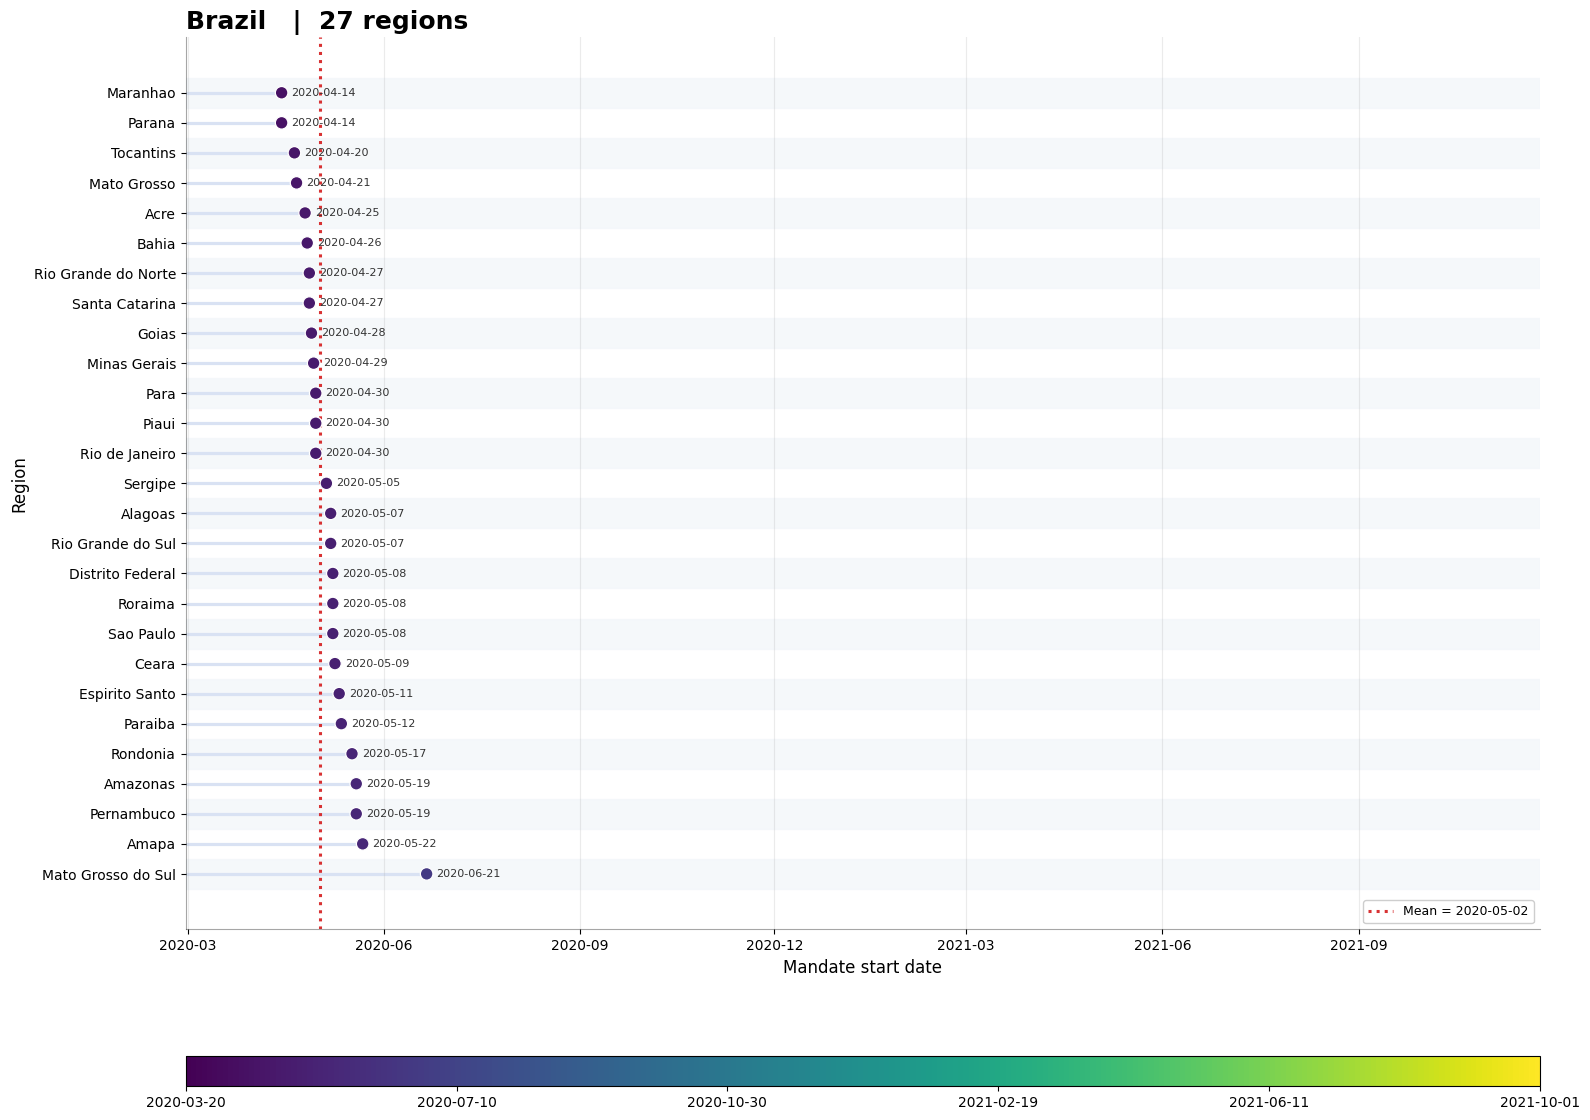

In [14]:
Region_mandate_date("Brazil")

### 4.4 Canada

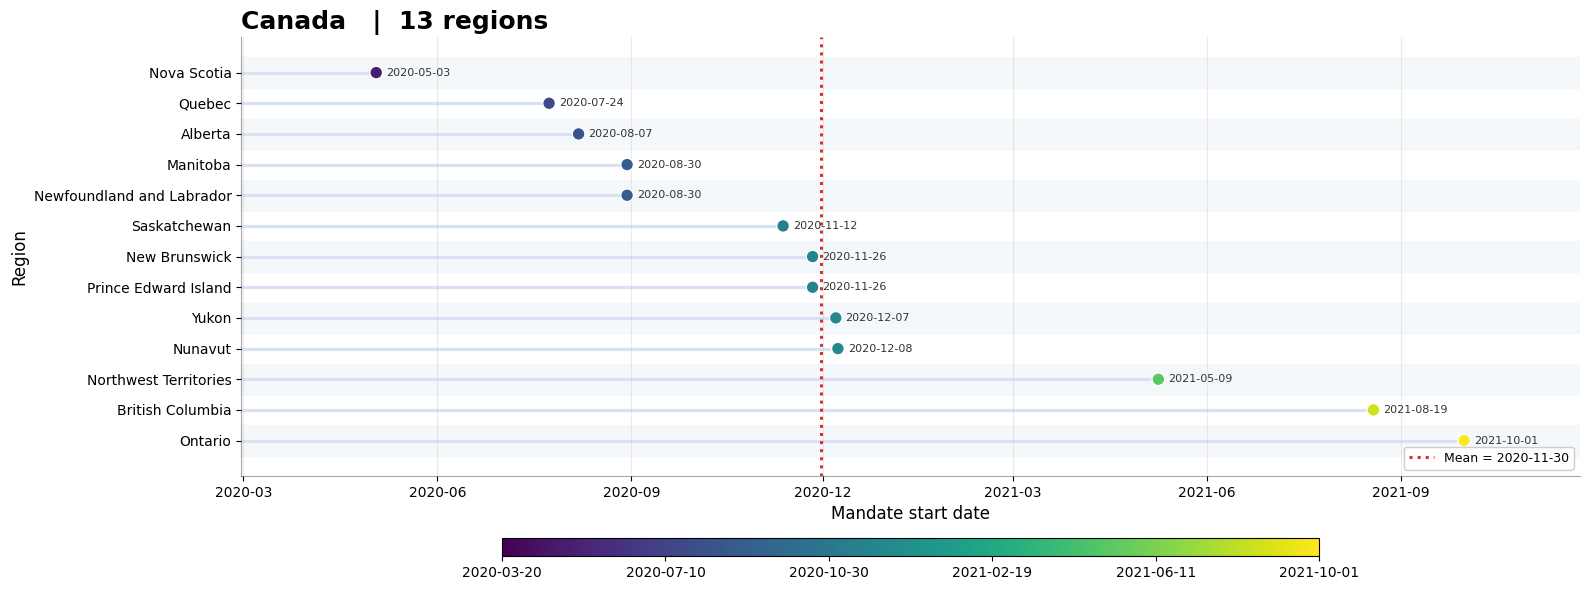

In [15]:
Region_mandate_date("Canada")

### 4.5 United Kingdom

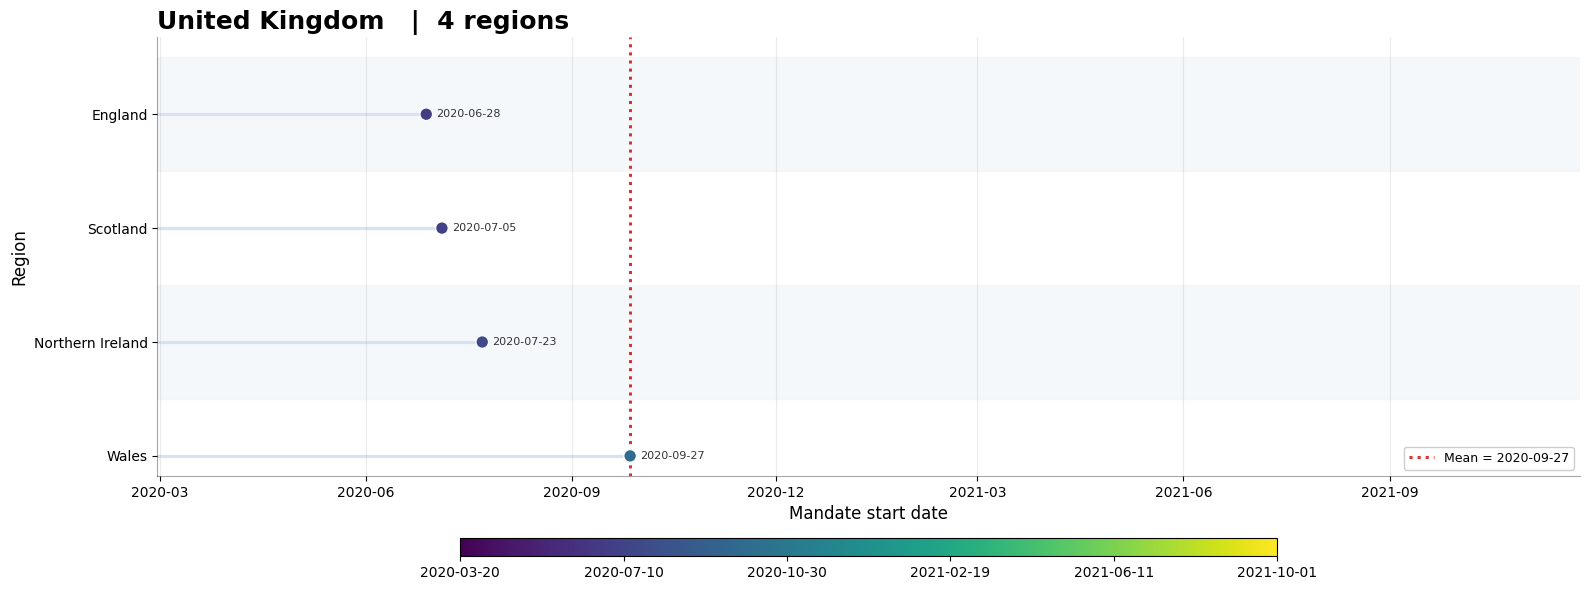

In [16]:
Region_mandate_date("United Kingdom")

### 4.6 India

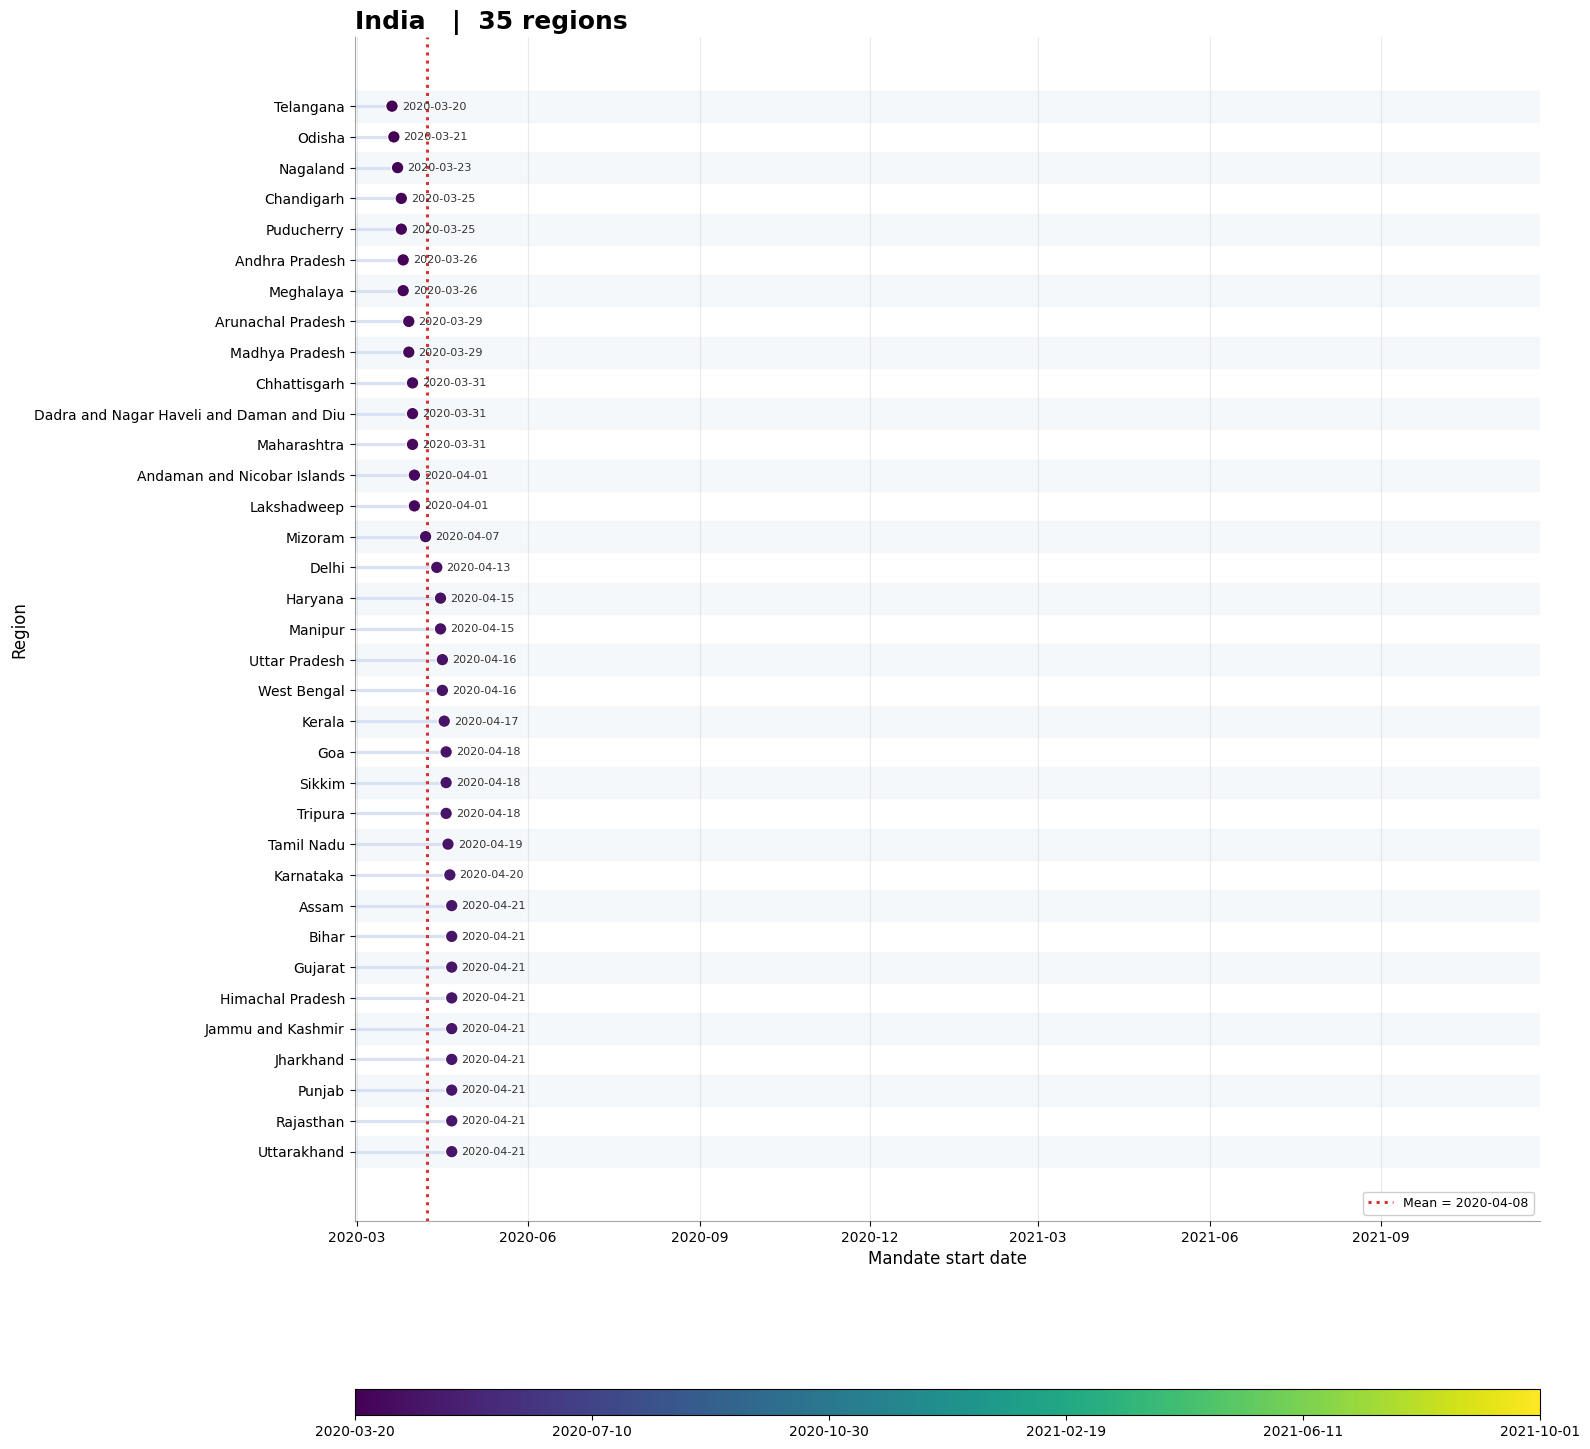

In [17]:
Region_mandate_date("India")

### 4.7 United States

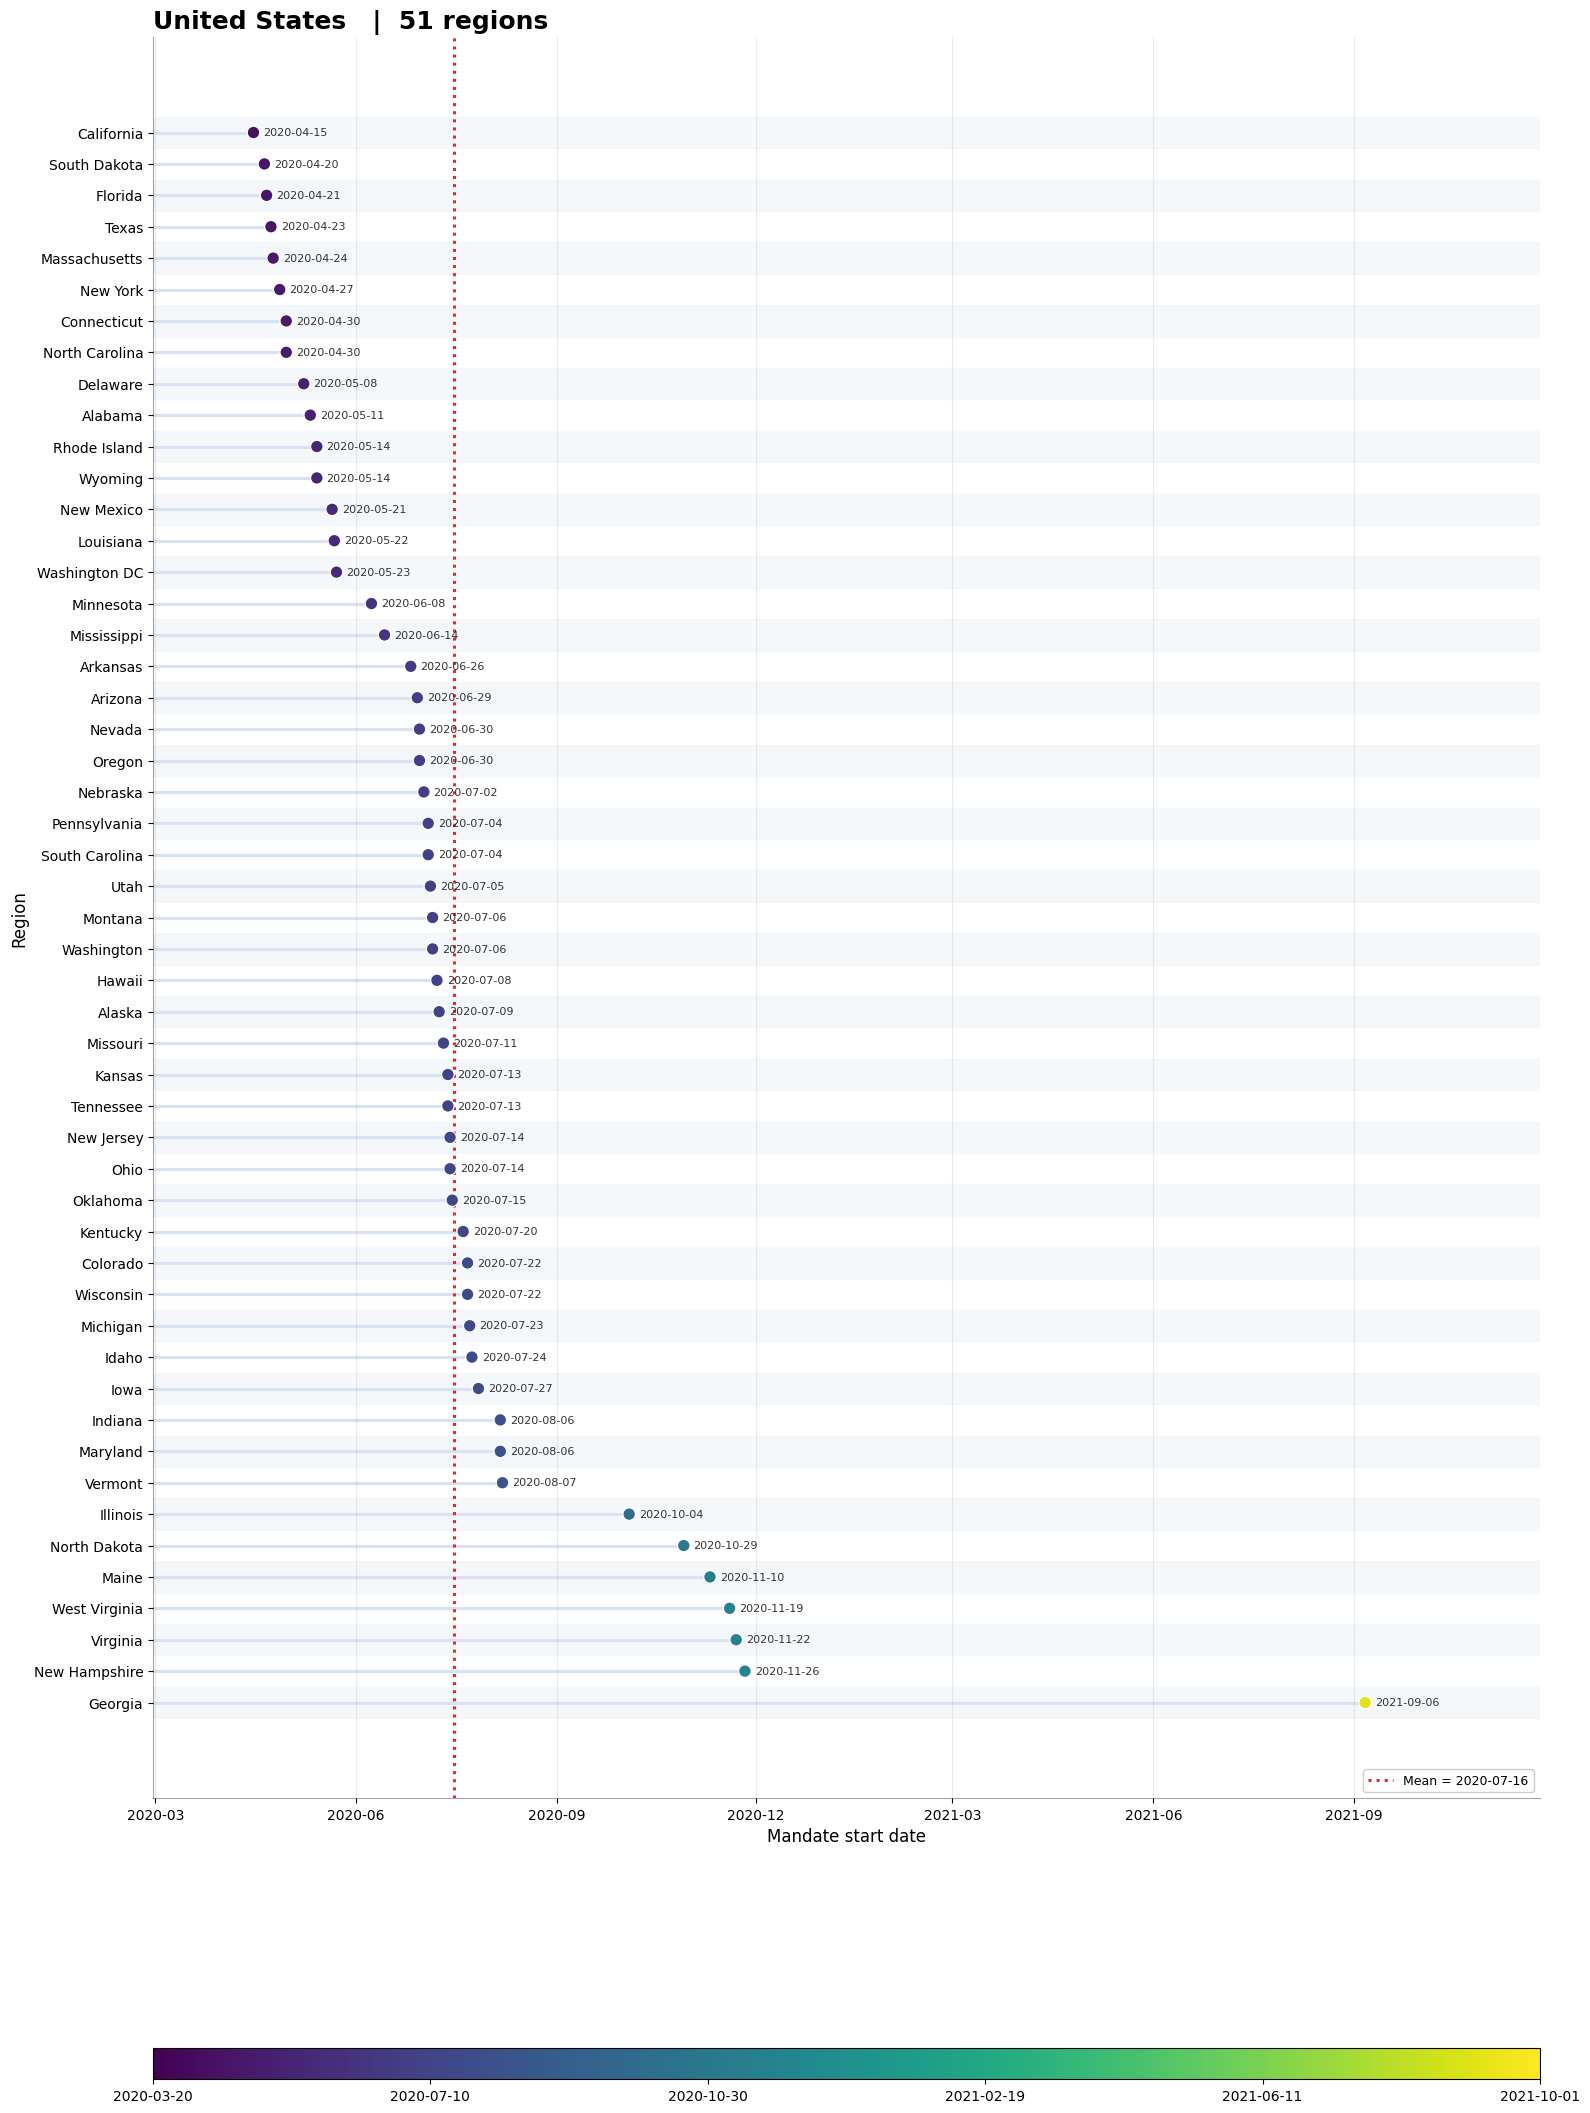

In [18]:
Region_mandate_date("United States")